# Training and Tuning Predictive Models


Installation: You will need to install python and jupyter. The easiest way is to install the package Anaconda as follows.

Download Anaconda from this link
Install Anaconda from the downloaded file
Open Jupyter Lab by

- (1) Click to the Start Windows Logo and Type in Anconda Promp. Open Anaconda Promp
- (2) In Anaconda Promp, type in: jupyter lab and hit Enter

Data: The data should be in the same folder as the notebook.



In [1]:
# import some packages
import pandas as pd
import numpy as np
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics

In [2]:
# Import the data
df = pd.read_csv('titanic.csv')

In [10]:
# Assign input variables
X = df.loc[:,['Pclass','Sex','Age','Fare','Embarked','SibSp','Parch']]

# Assign target variable
y = df['Survived']

In [11]:
# Change Pclass to categorical variable
X['Pclass'] = X['Pclass'].astype(object)

In [12]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [13]:
# Replace missing values by the median
X["Age"] = X["Age"].fillna(X["Age"].median())

# Impute the Embarked variable
X["Embarked"] = X["Embarked"].fillna("S")

In [14]:
X

,Pclass,Sex,Age,Fare,Embarked,SibSp,Parch
0,3,male,22.0,7.2500,S,1,0
1,1,female,38.0,71.2833,C,1,0
2,3,female,26.0,7.9250,S,0,0
3,1,female,35.0,53.1000,S,1,0
4,3,male,35.0,8.0500,S,0,0
...,...,...,...,...,...,...,...
886,2,male,27.0,13.0000,S,0,0
887,1,female,19.0,30.0000,S,0,0
888,3,female,28.0,23.4500,S,1,2
889,1,male,26.0,30.0000,C,0,0


In [15]:
# Encode categorical variable
X = pd.get_dummies(X)

C:\Users\snguyen4\Anaconda3_fa22\lib\site-packages\pandas\core\algorithms.py:798: FutureWarning: In a future version, the Index constructor will not infer numeric dtypes when passed object-dtype sequences (matching Series behavior)
  uniques = Index(uniques)


In [16]:
X

,Age,Fare,SibSp,Parch,Pclass_1,Pclass_2,Pclass_3,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,22.0,7.2500,1,0,0,0,1,0,1,0,0,1
1,38.0,71.2833,1,0,1,0,0,1,0,1,0,0
2,26.0,7.9250,0,0,0,0,1,1,0,0,0,1
3,35.0,53.1000,1,0,1,0,0,1,0,0,0,1
4,35.0,8.0500,0,0,0,0,1,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
886,27.0,13.0000,0,0,0,1,0,0,1,0,0,1
887,19.0,30.0000,0,0,1,0,0,1,0,0,0,1
888,28.0,23.4500,1,2,0,0,1,1,0,0,0,1
889,26.0,30.0000,0,0,1,0,0,0,1,1,0,0


In [18]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.3)

In [29]:
# Create a decision tree and train
tree1 = DecisionTreeClassifier(criterion='entropy', max_leaf_nodes=10)
tree1.fit(x_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_leaf_nodes=10)

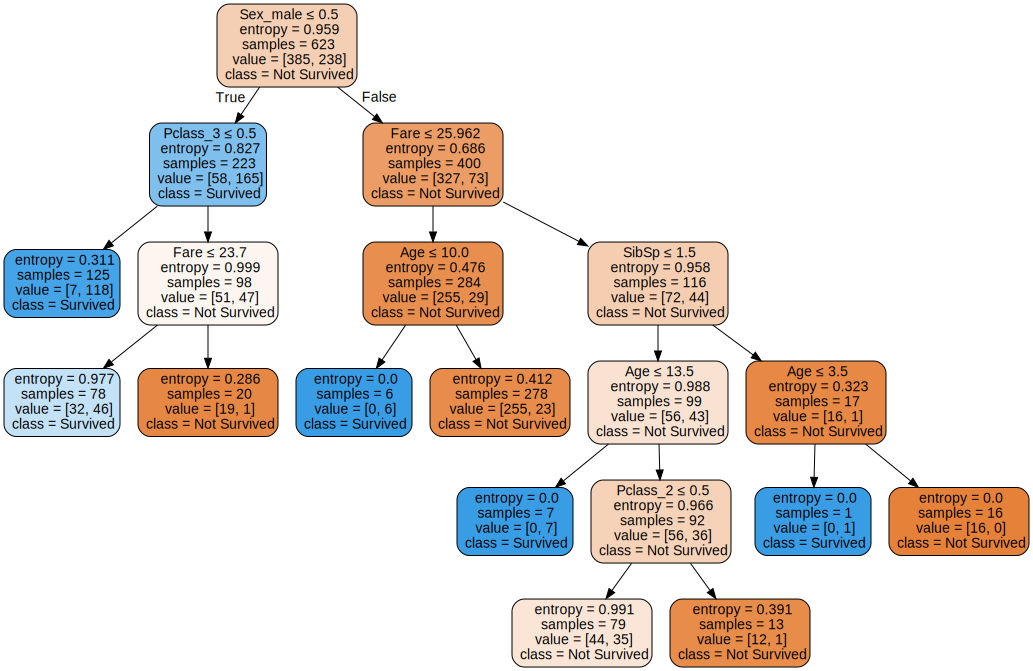

In [30]:
from sklearn import tree

import graphviz 

dot_data = tree.export_graphviz(tree1, out_file=None) 
dot_data = tree.export_graphviz(tree1, out_file=None, 
                     feature_names=x_train.columns,  
                     class_names=['Not Survived','Survived'],  
                     filled=True, rounded=True,  
                     special_characters=True)  

graph = graphviz.Source(dot_data)  

graph

In [31]:
# Prediction and accuracy on testing data

print('Testing Accuracy is:')
tree1.score(x_test, y_test)

Testing Accuracy is:


0.7910447761194029

In [36]:
import warnings
warnings.filterwarnings("ignore")


# Decide what hyperparameter to tune then decide the searching range
param_grid = {'max_leaf_nodes': range(2,21), 
              'criterion':['gini', 'entropy']}

# Create a list of trees
from sklearn.model_selection import GridSearchCV
tree2 = GridSearchCV(DecisionTreeClassifier(), param_grid, cv = 5)
tree2.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_leaf_nodes': range(2, 21)})

In [37]:
cv_result = pd.concat([pd.DataFrame(tree2.cv_results_["params"]),pd.DataFrame(tree2.cv_results_["mean_test_score"], columns=["Accuracy"])],axis=1)
cv_result['Rank'] = (-cv_result['Accuracy']).argsort().argsort()
cv_result

,criterion,max_leaf_nodes,Accuracy,Rank
0,gini,2,0.789729,33
1,gini,3,0.780155,34
2,gini,4,0.776955,37
3,gini,5,0.804245,30
4,gini,6,0.812297,28
5,gini,7,0.812297,29
6,gini,8,0.821910,17
7,gini,9,0.821923,13
8,gini,10,0.823561,12
9,gini,11,0.829961,9


In [38]:
tree2.best_params_

{'criterion': 'gini', 'max_leaf_nodes': 15}

Best Tree is: {'criterion': 'gini', 'max_leaf_nodes': 15}



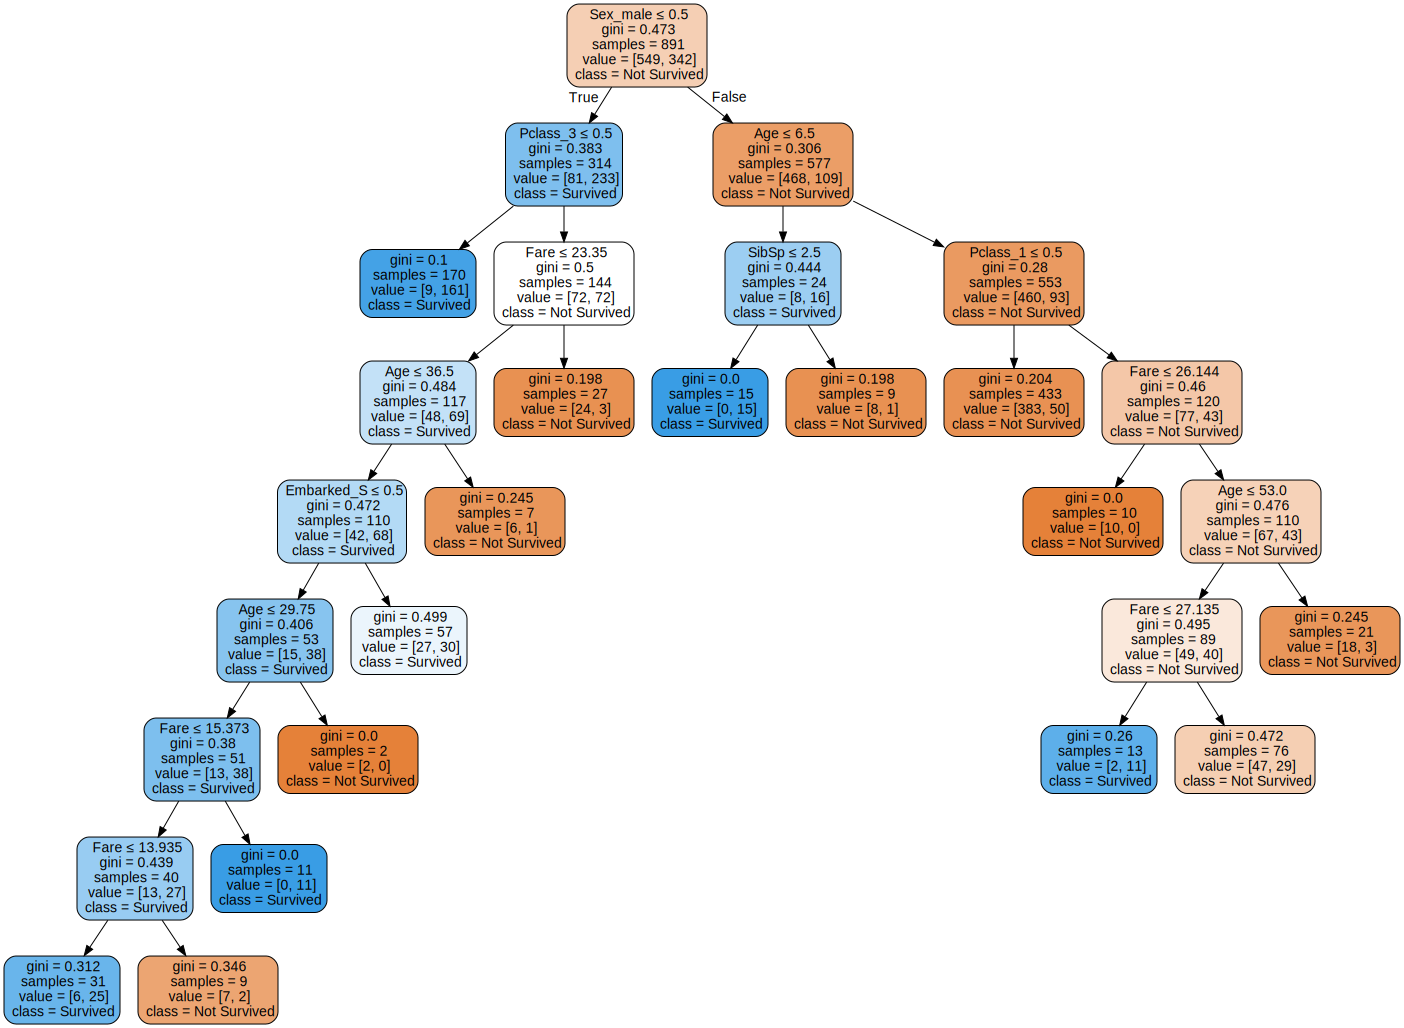

In [39]:
tree3 = DecisionTreeClassifier(**tree2.best_params_)

# Train with the selected hyperparameter
tree3.fit(X, y)

print('Best Tree is:', tree2.best_params_)
print('')
import graphviz 
dot_data = tree.export_graphviz(tree3, out_file=None) 
dot_data = tree.export_graphviz(tree3, out_file=None, 
                     feature_names=x_train.columns,  
                     class_names=['Not Survived','Survived'],  
                     filled=True, rounded=True,  
                     special_characters=True)  

graph = graphviz.Source(dot_data)  

graph